In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('advertising.csv')

# Look at the first few rows
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [2]:
# Check for missing values
df.isnull().sum()

# Summary statistics
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


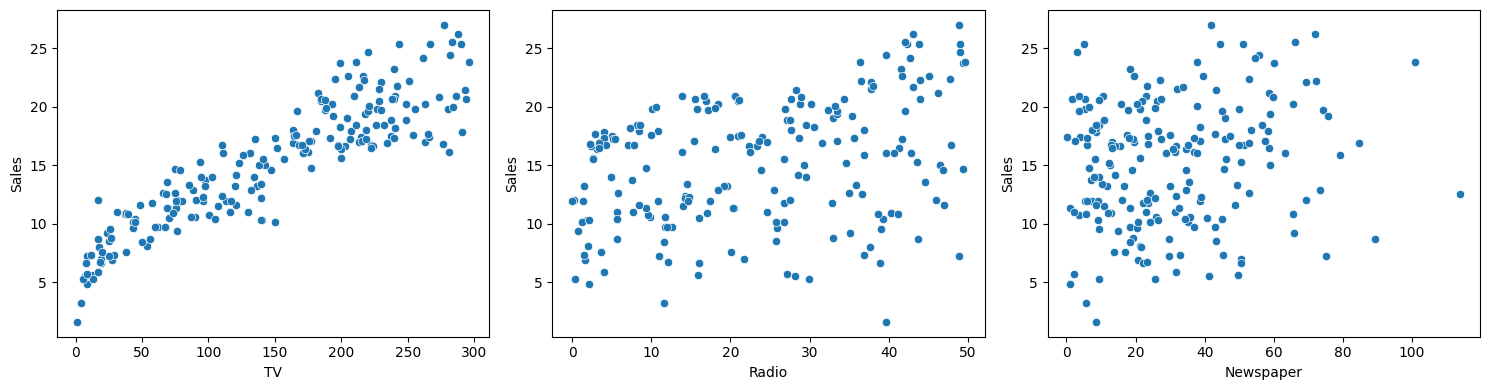

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(x='TV', y='Sales', data=df, ax=axes[0])
sns.scatterplot(x='Radio', y='Sales', data=df, ax=axes[1])
sns.scatterplot(x='Newspaper', y='Sales', data=df, ax=axes[2])
plt.tight_layout()
plt.savefig('sales_scatter.png')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# See which features matter most
coefficients = pd.Series(model.coef_, index=X.columns)
print("\nCoefficients:\n", coefficients)

R² Score: 0.9059011844150826
Mean Squared Error: 2.9077569102710896

Coefficients:
 TV           0.054509
Radio        0.100945
Newspaper    0.004337
dtype: float64
